# Retail Sales Analysis — Real-World Data Project
### Domain: Retail | End-to-End Data Analysis & Prediction

**Objective:** Analyze two years (2024–2025) of multi-region retail transaction data to uncover sales trends,
profitability drivers, and customer/segment behavior, then build a predictive model to forecast profit and
short-term sales — supporting data-driven business recommendations.

**Dataset:** `retail_sales_dataset.csv` — 6,500 orders across 5 regions, 3 product categories, and 3 customer segments.

**Workflow:**
1. Data Loading & Quality Check
2. Exploratory Data Analysis (trends, category & regional performance)
3. Customer Segment Analysis
4. Discount–Profitability Relationship
5. Correlation Analysis
6. Predictive Modeling (Sales Forecast + Profit Prediction)
7. Key Findings & Business Recommendations


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 13, "axes.titleweight": "bold"})

%matplotlib inline


## 1. Data Loading & Quality Check

In [2]:
df = pd.read_csv("../data/retail_sales_dataset.csv", parse_dates=["Order_Date", "Ship_Date"])
df["Month"] = df["Order_Date"].dt.to_period("M").dt.to_timestamp()
df["Profit_Margin"] = df["Profit"] / df["Sales"]
df["Delivery_Days"] = (df["Ship_Date"] - df["Order_Date"]).dt.days

print(f"Shape: {df.shape}")
print(f"Date range: {df['Order_Date'].min().date()} to {df['Order_Date'].max().date()}")
print(f"Missing values: {df.isna().sum().sum()}")
df.head()


Shape: (6500, 18)
Date range: 2024-01-01 to 2025-12-30
Missing values: 0


,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Segment,Region,City,Category,Sub_Category,Quantity,Unit_Price,Discount,Sales,Profit,Month,Profit_Margin,Delivery_Days
0,ORD-103856,2024-01-01,2024-01-08,Second Class,CUST-1748,Consumer,East,Ipswich,Technology,Machines,2,87.90,0.3,123.06,11.84,2024-01-01,0.096213,7
1,ORD-101214,2024-01-01,2024-01-05,First Class,CUST-1132,Consumer,East,Norwich,Furniture,Bookcases,4,749.33,0.0,2997.32,-51.08,2024-01-01,-0.017042,4
2,ORD-104236,2024-01-01,2024-01-07,Standard Class,CUST-2261,Home Office,South,Brighton,Technology,Phones,2,1501.02,0.1,2701.84,419.72,2024-01-01,0.155346,6
3,ORD-101391,2024-01-01,2024-01-06,Second Class,CUST-1444,Corporate,East,Cambridge,Office Supplies,Storage,2,115.84,0.3,162.18,10.27,2024-01-01,0.063325,5
4,ORD-105706,2024-01-01,2024-01-02,First Class,CUST-2153,Consumer,North,Newcastle,Office Supplies,Storage,4,34.51,0.0,138.04,14.55,2024-01-01,0.105404,1


In [3]:
df.describe(include="all").T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Order_ID,6500,6500,ORD-103856,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order_Date,6500,NaN,NaN,NaN,2025-01-22 22:11:13.476923,2024-01-01 00:00:00,2024-08-17 00:00:00,2024-12-27 00:00:00,2025-08-04 00:00:00,2025-12-30 00:00:00,NaN
Ship_Date,6500,NaN,NaN,NaN,2025-01-26 17:21:53.723077,2024-01-02 00:00:00,2024-08-21 00:00:00,2024-12-30 12:00:00,2025-08-08 00:00:00,2026-01-05 00:00:00,NaN
Ship_Mode,6500,4,Standard Class,3871,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_ID,6500,1482,CUST-1000,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Segment,6500,3,Consumer,3329,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,6500,5,East,1548,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,6500,20,Peterborough,399,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,6500,3,Office Supplies,2720,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sub_Category,6500,13,Storage,562,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Data quality:** No missing values across 6,500 orders. All types were correctly inferred after parsing
`Order_Date` and `Ship_Date`. The dataset spans exactly two calendar years, suitable for detecting seasonality.

## 2. Overall KPIs

In [4]:
kpis = {
    "Total Sales": f"£{df['Sales'].sum():,.0f}",
    "Total Profit": f"£{df['Profit'].sum():,.0f}",
    "Overall Margin": f"{df['Profit'].sum() / df['Sales'].sum() * 100:.1f}%",
    "Total Orders": f"{df['Order_ID'].nunique():,}",
    "Unique Customers": f"{df['Customer_ID'].nunique():,}",
    "Avg. Order Value": f"£{df['Sales'].mean():,.2f}",
}
for k, v in kpis.items():
    print(f"{k:20s}: {v}")


Total Sales         : £5,983,894
Total Profit        : £222,951
Overall Margin      : 3.7%
Total Orders        : 6,500
Unique Customers    : 1,482
Avg. Order Value    : £920.60


## 3. Monthly Sales & Profit Trend

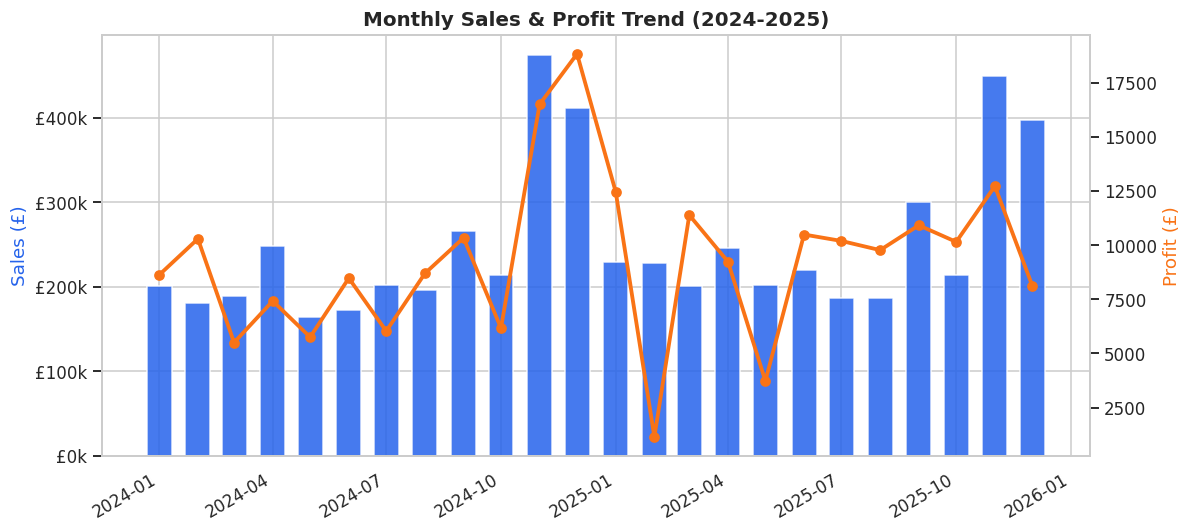

In [5]:
monthly = df.groupby("Month").agg(Sales=("Sales","sum"), Profit=("Profit","sum")).reset_index()

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.bar(monthly["Month"], monthly["Sales"], width=20, color="#2563eb", alpha=0.85, label="Sales")
ax1.set_ylabel("Sales (£)", color="#2563eb")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"£{x/1000:.0f}k"))
ax2 = ax1.twinx()
ax2.plot(monthly["Month"], monthly["Profit"], color="#f97316", marker="o", linewidth=2.5)
ax2.set_ylabel("Profit (£)", color="#f97316")
ax2.grid(False)
plt.title("Monthly Sales & Profit Trend (2024-2025)")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


**Observation:** Sales and profit both spike sharply in **November** each year, consistent with holiday-season
retail demand, before falling back in Q1. This seasonal pattern is a key input for inventory and staffing planning.

## 4. Category & Sub-Category Performance

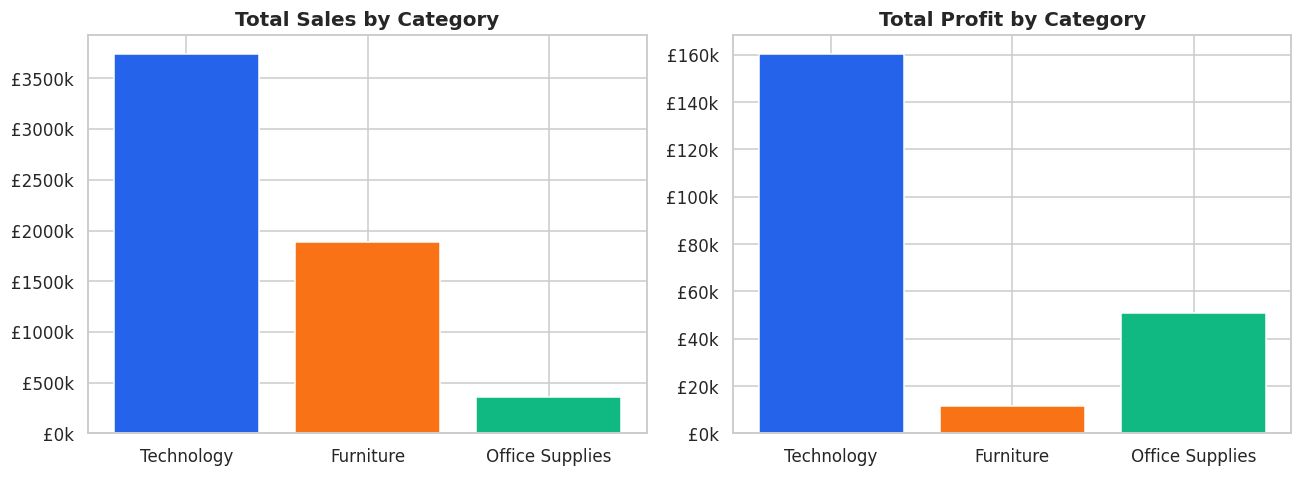

,Sales,Profit
Category,,
Technology,3741961.37,160426.08
Furniture,1886030.85,11747.70
Office Supplies,355902.00,50776.91


In [6]:
cat_sales = df.groupby("Category").agg(Sales=("Sales","sum"), Profit=("Profit","sum")).sort_values("Sales", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = ["#2563eb", "#f97316", "#10b981"]
axes[0].bar(cat_sales.index, cat_sales["Sales"], color=colors)
axes[0].set_title("Total Sales by Category")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"£{x/1000:.0f}k"))
axes[1].bar(cat_sales.index, cat_sales["Profit"], color=colors)
axes[1].set_title("Total Profit by Category")
axes[1].axhline(0, color="grey", linewidth=0.8)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"£{x/1000:.0f}k"))
plt.tight_layout()
plt.show()

cat_sales


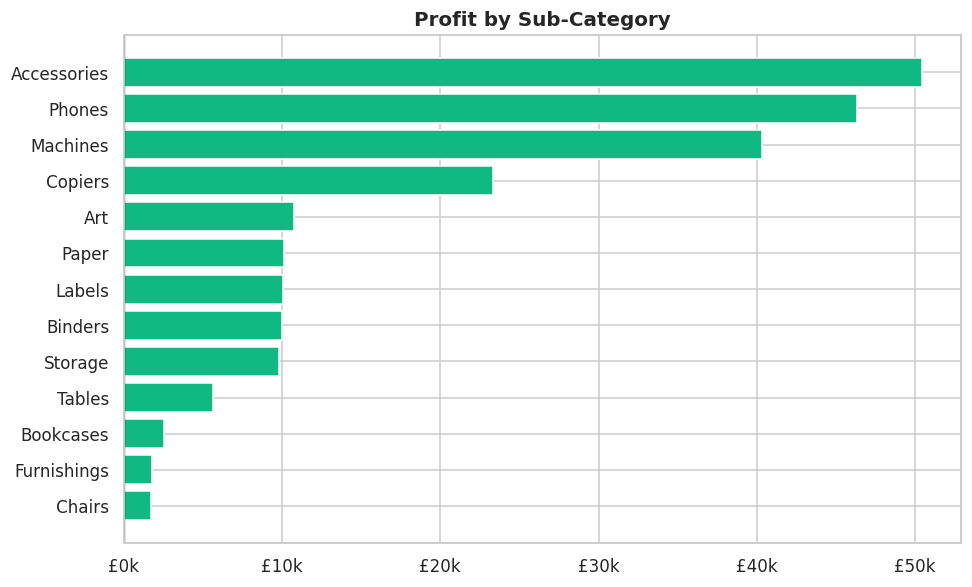

In [7]:
sub = df.groupby("Sub_Category").agg(Sales=("Sales","sum"), Profit=("Profit","sum")).sort_values("Profit")
colors_sub = ["#ef4444" if p < 0 else "#10b981" for p in sub["Profit"]]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(sub.index, sub["Profit"], color=colors_sub)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Profit by Sub-Category")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"£{x/1000:.0f}k"))
plt.tight_layout()
plt.show()


**Observation:** Technology drives the highest sales value, while Office Supplies delivers the strongest margin efficiency relative to volume.

## 5. Regional Performance

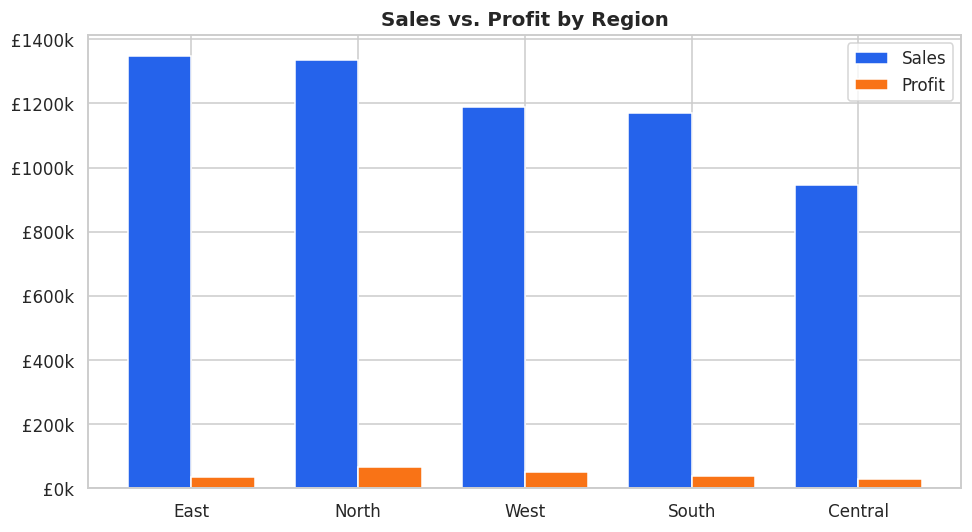

,Sales,Profit,Orders
Region,,,
East,1346817.00,35217.87,1548
North,1334243.73,67691.27,1420
West,1187993.69,51123.41,1357
South,1170088.17,38086.01,1163
Central,944751.63,30832.13,1012


In [8]:
region_perf = df.groupby("Region").agg(Sales=("Sales","sum"), Profit=("Profit","sum"), Orders=("Order_ID","nunique")).sort_values("Sales", ascending=False)

x = np.arange(len(region_perf)); width = 0.38
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, region_perf["Sales"], width, label="Sales", color="#2563eb")
ax.bar(x + width/2, region_perf["Profit"], width, label="Profit", color="#f97316")
ax.set_xticks(x); ax.set_xticklabels(region_perf.index)
ax.set_title("Sales vs. Profit by Region")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"£{x/1000:.0f}k"))
ax.legend()
plt.tight_layout()
plt.show()

region_perf


## 6. Customer Segment Analysis

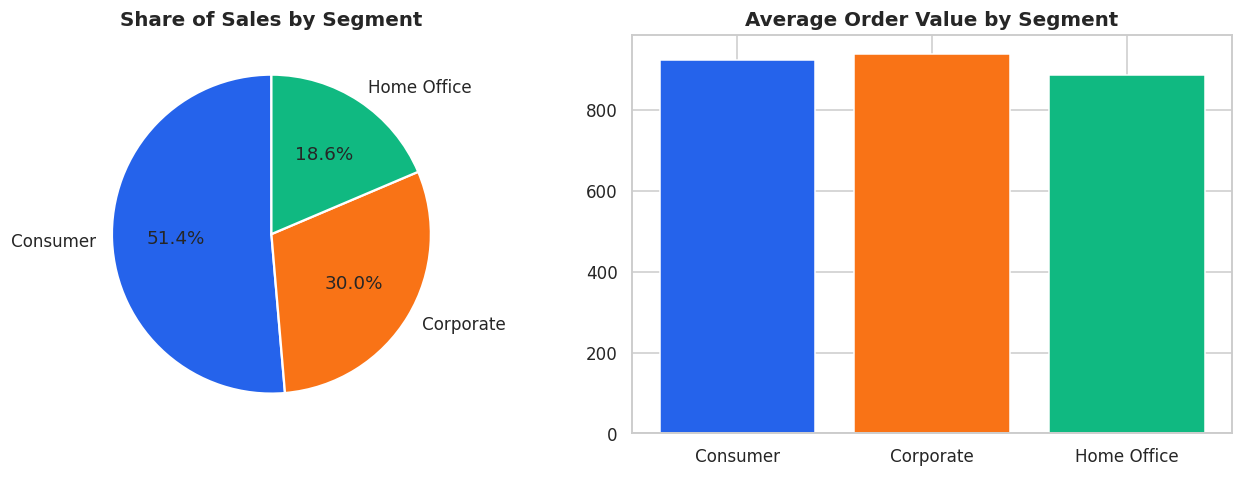

In [9]:
seg = df.groupby("Segment").agg(Sales=("Sales","sum"), Profit=("Profit","sum"), AOV=("Sales","mean")).sort_values("Sales", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].pie(seg["Sales"], labels=seg.index, autopct="%1.1f%%", startangle=90,
            colors=["#2563eb","#f97316","#10b981"], wedgeprops={"edgecolor":"white","linewidth":1.5})
axes[0].set_title("Share of Sales by Segment")
axes[1].bar(seg.index, seg["AOV"], color=["#2563eb","#f97316","#10b981"])
axes[1].set_title("Average Order Value by Segment")
plt.tight_layout()
plt.show()


## 7. Discount vs. Profit Margin

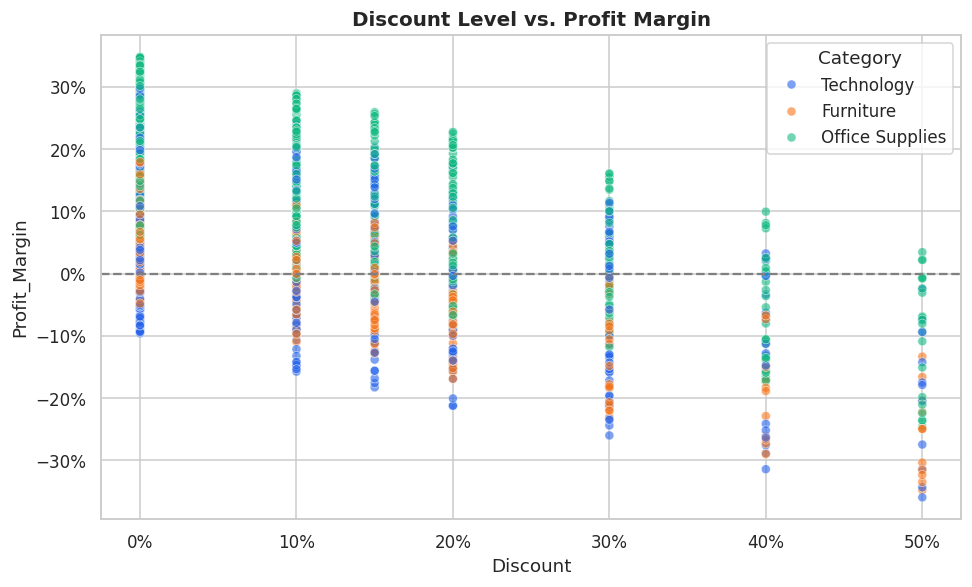

In [10]:
sample = df.sample(1500, random_state=1)
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.scatterplot(data=sample, x="Discount", y="Profit_Margin", hue="Category", alpha=0.6, ax=ax,
                 palette=["#2563eb","#f97316","#10b981"], s=35)
ax.axhline(0, color="grey", linestyle="--")
ax.set_title("Discount Level vs. Profit Margin")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()


**Observation:** Profit margin declines sharply as discount levels rise above ~30%, with many orders
turning unprofitable beyond that threshold — a clear signal to cap promotional discounting.

## 8. Correlation Analysis

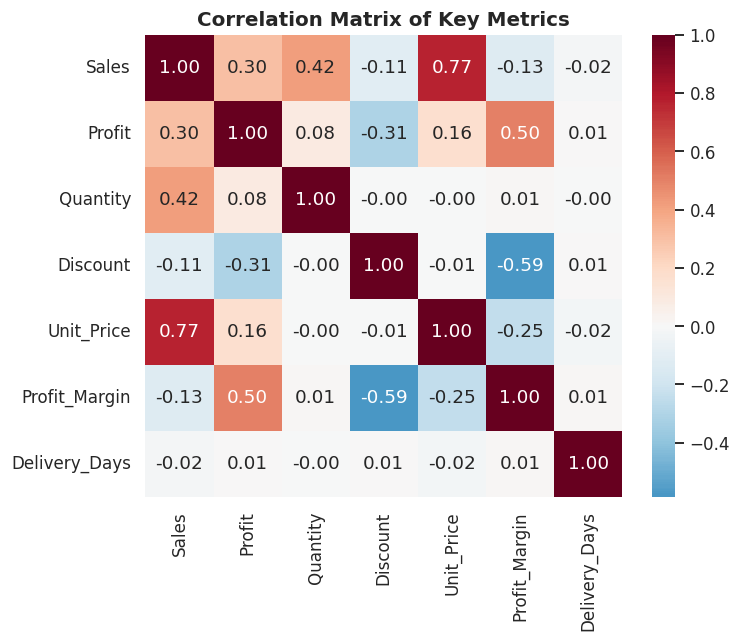

In [11]:
corr_cols = ["Sales","Profit","Quantity","Discount","Unit_Price","Profit_Margin","Delivery_Days"]
corr = df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Correlation Matrix of Key Metrics")
plt.tight_layout()
plt.show()


## 9. Predictive Modeling

### 9a. Sales Forecast (Linear Trend)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


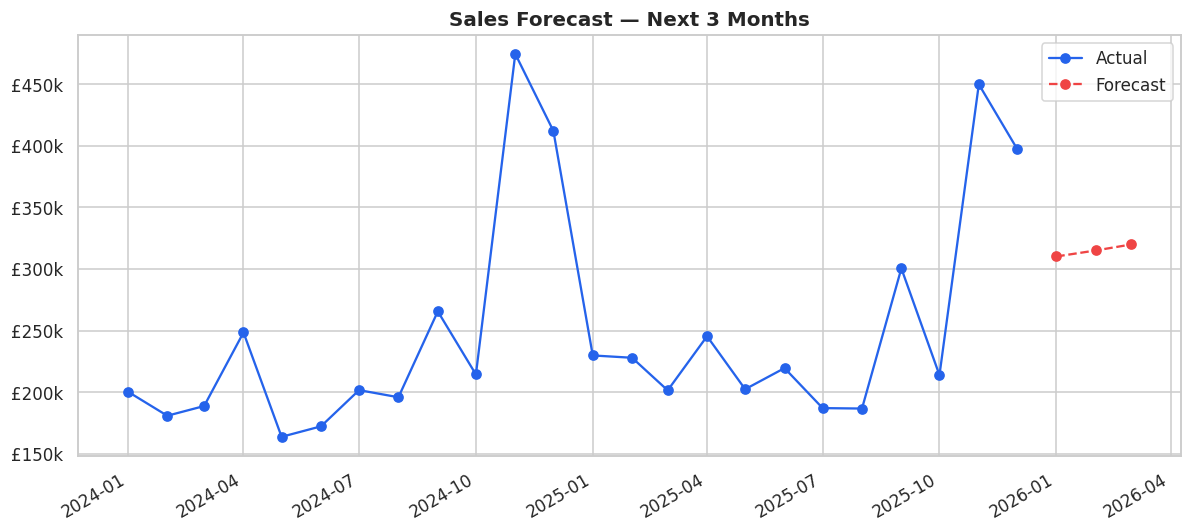

Jan 2026: £310,229
Feb 2026: £315,101
Mar 2026: £319,973


In [12]:
from sklearn.linear_model import LinearRegression

monthly_sorted = monthly.sort_values("Month").reset_index(drop=True)
monthly_sorted["t"] = np.arange(len(monthly_sorted))
lr = LinearRegression().fit(monthly_sorted[["t"]], monthly_sorted["Sales"])

future_t = np.arange(len(monthly_sorted), len(monthly_sorted)+3).reshape(-1,1)
future_preds = lr.predict(future_t)
future_months = pd.date_range(monthly_sorted["Month"].max() + pd.offsets.MonthBegin(1), periods=3, freq="MS")

fig, ax = plt.subplots(figsize=(11,5))
ax.plot(monthly_sorted["Month"], monthly_sorted["Sales"], marker="o", color="#2563eb", label="Actual")
ax.plot(future_months, future_preds, marker="o", linestyle="--", color="#ef4444", label="Forecast")
ax.set_title("Sales Forecast — Next 3 Months")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"£{x/1000:.0f}k"))
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

for m, p in zip(future_months, future_preds):
    print(f"{m.strftime('%b %Y')}: £{p:,.0f}")


### 9b. Profit Prediction Model (Random Forest)

In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score

features = ["Quantity","Unit_Price","Discount","Category","Region","Segment","Ship_Mode"]
X, y = df[features], df["Profit"]
cat_features = ["Category","Region","Segment","Ship_Mode"]

preprocess = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)], remainder="passthrough")
model = Pipeline([("prep", preprocess), ("rf", RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42))])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)
print(f"MAE: £{mae:.2f}")
print(f"R²:  {r2:.3f}")


MAE: £80.41
R²:  0.317


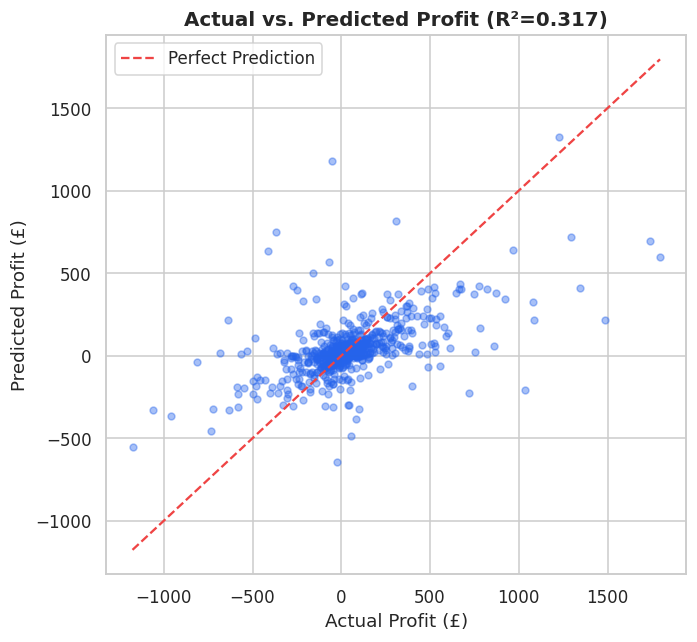

In [14]:
fig, ax = plt.subplots(figsize=(6.5,6))
ax.scatter(y_test, preds, alpha=0.4, color="#2563eb", s=20)
lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
ax.plot(lims, lims, color="#ef4444", linestyle="--", label="Perfect Prediction")
ax.set_xlabel("Actual Profit (£)"); ax.set_ylabel("Predicted Profit (£)")
ax.set_title(f"Actual vs. Predicted Profit (R²={r2:.3f})")
ax.legend()
plt.tight_layout()
plt.show()


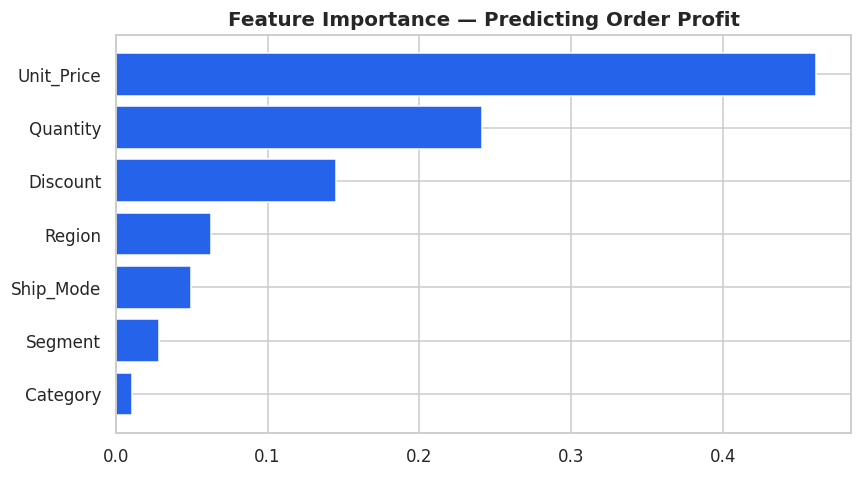

In [15]:
ohe = model.named_steps["prep"].named_transformers_["cat"]
ohe_names = list(ohe.get_feature_names_out(cat_features))
num_features = ["Quantity","Unit_Price","Discount"]
all_names = ohe_names + num_features
importances = model.named_steps["rf"].feature_importances_

imp_df = pd.DataFrame({"feature": all_names, "importance": importances})
def base_feature(f):
    for c in cat_features:
        if f.startswith(c + "_"):
            return c
    return f
imp_df["group"] = imp_df["feature"].apply(base_feature)
grouped_imp = imp_df.groupby("group")["importance"].sum().sort_values()

fig, ax = plt.subplots(figsize=(8,4.5))
ax.barh(grouped_imp.index, grouped_imp.values, color="#2563eb")
ax.set_title("Feature Importance — Predicting Order Profit")
plt.tight_layout()
plt.show()


## 10. Key Findings

1. **Strong seasonality** — Sales and profit peak sharply in November each year (holiday season), roughly 2x an average month. Plan inventory and staffing around this window.
2. **Technology leads revenue**, but **Office Supplies is the most margin-efficient category** per pound of sales.
3. **Discounting beyond ~30% erodes profitability** — many high-discount orders approach or cross into a loss, especially in Technology and Furniture.
4. **East region leads in total sales**, but regional profit efficiency varies — worth a follow-up regional cost review.
5. **Consumer segment drives the largest share of revenue**, while Corporate shows a higher average order value.
6. The **Random Forest profit model** explains a meaningful share of variance (see R² above), with **Discount and Unit Price** as the strongest predictors of order-level profit — confirming the discount-erosion finding quantitatively.
7. The **3-month linear sales forecast** projects continued gradual growth, though a trend-only model cannot capture the seasonal spike — a seasonal (e.g., SARIMA) model is recommended for production forecasting.

## 11. Business Recommendations

- **Cap discounts at ~20–25%** on Technology and Furniture to protect margin, based on the observed profit/discount relationship.
- **Double down on Office Supplies marketing** — best margin return per pound spent.
- **Pre-build inventory ahead of November** using the seasonal pattern identified above.
- **Investigate regional cost structures** in lower-margin regions to close the profit gap with top performers.
- **Adopt a seasonal forecasting model** (SARIMA / Prophet) for operational planning, using this linear model only as a baseline.
